In [ ]:
import os
import requests
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit.cost import LeastSquares
from scipy.stats import chi2
import scipy as s
import scipy.stats as sc
from scipy.stats import chi2 as chi2_dist
from scipy.stats import t,norm
plt.rcParams['text.usetex'] = False
try:
    import Uomo_lucertola_vecchia as lib2
    print('Successo Importazione')
except ModuleNotFoundError:
    print(f"ERRORE: Impossibile trovare il modulo Uomo_lucertola. Assicurati che 'Uomo_lucertola.py' sia nella stessa cartella del notebook: {os.getcwd()}")
try:
    import Uomo_lucertola as lib
    print('Successo Importazione 2')
except ModuleNotFoundError:
    print(f"ERRORE: Impossibile trovare il modulo Uomo_lucertola2. Assicurati che 'Uomo_lucertola2.py' sia nella stessa cartella del notebook: {os.getcwd()}")


import uncertainties
from uncertainties import ufloat, correlated_values
from uncertainties import ufloat
from uncertainties import unumpy

import importlib
import Uomo_lucertola as lib
#importlib.reload(lib)

Successo Importazione
Successo Importazione 2


<module 'Uomo_lucertola' from 'c:\\Users\\Andrea\\Desktop\\lab nucleare\\Uomo_lucertola.py'>

In [2]:
cartella_dati = "misure"

#  Analisi con tensione, gain costante e shaping time variabile

# Rivelatore PICCOLO (1)

In [ ]:
# Adesso cambiamo lo shaping time, 0.5 non c'è nulla. Sono in microsecondi
# La risoluzione energetica si scrive come R2 = sigma2 / mu2, sigma2 è proporzionale a 1/tau. Il termine Btau 
# è relativo al pileup. R2 = A/tau + Btau. Il minimo è per tau = sqrt(A/B)

distanza2 = ufloat(0.085, 0.001)
file_shaping_list = [
    "histo_1_gain750_st05.dat",
    "histo_1_gain750_st1.dat",
    "histo_1_gain750_st2.dat",
    "histo_1_gain750_st3.dat",
    "histo_1_gain750_st6.dat",
    "histo_1_gain750_st10.dat"
]


  Shaping-Time = 5e-07 (Taglio tra 2150 e 3200)


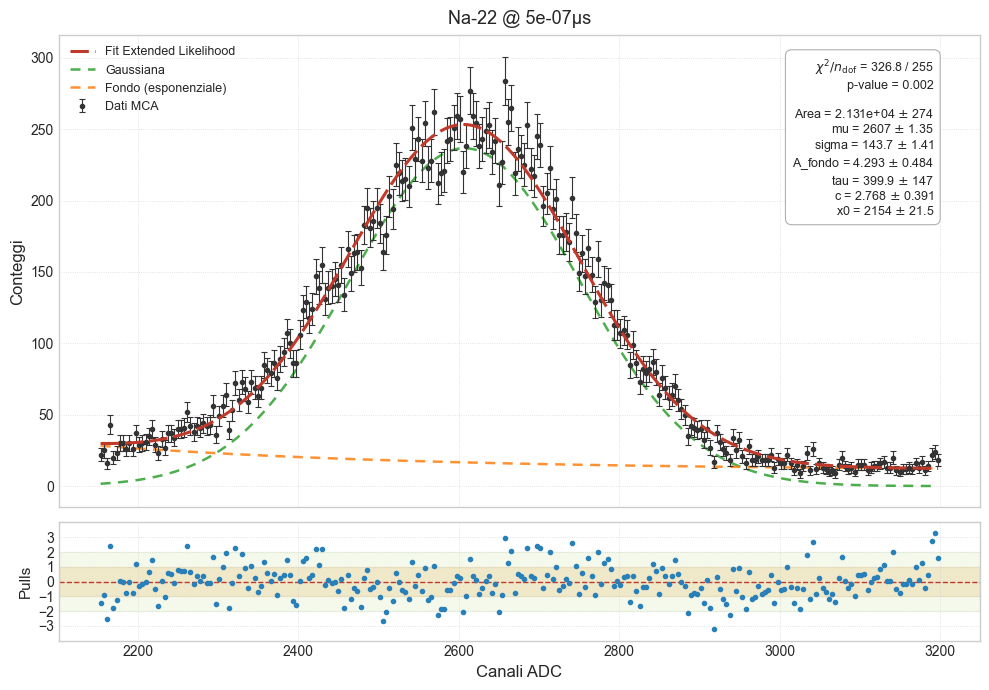

  → Risoluzione R = 0.1298+/-0.0013

  Shaping-Time = 1e-06 (Taglio tra 2600 e 3300)


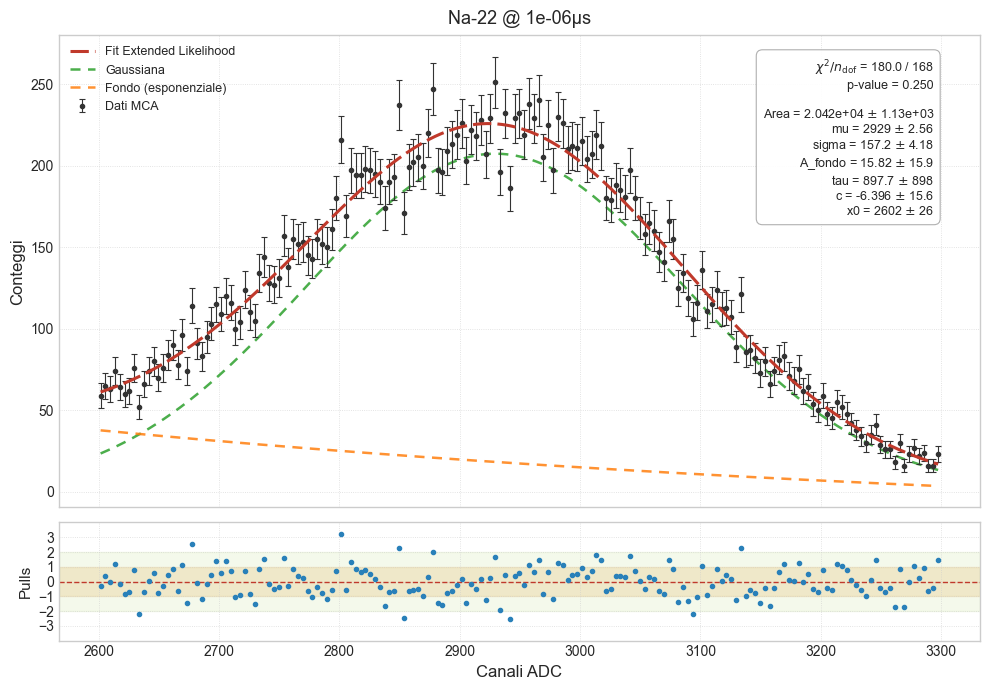

  → Risoluzione R = 0.1264+/-0.0034

  Shaping-Time = 2e-06 (Taglio tra 2500 e 3900)


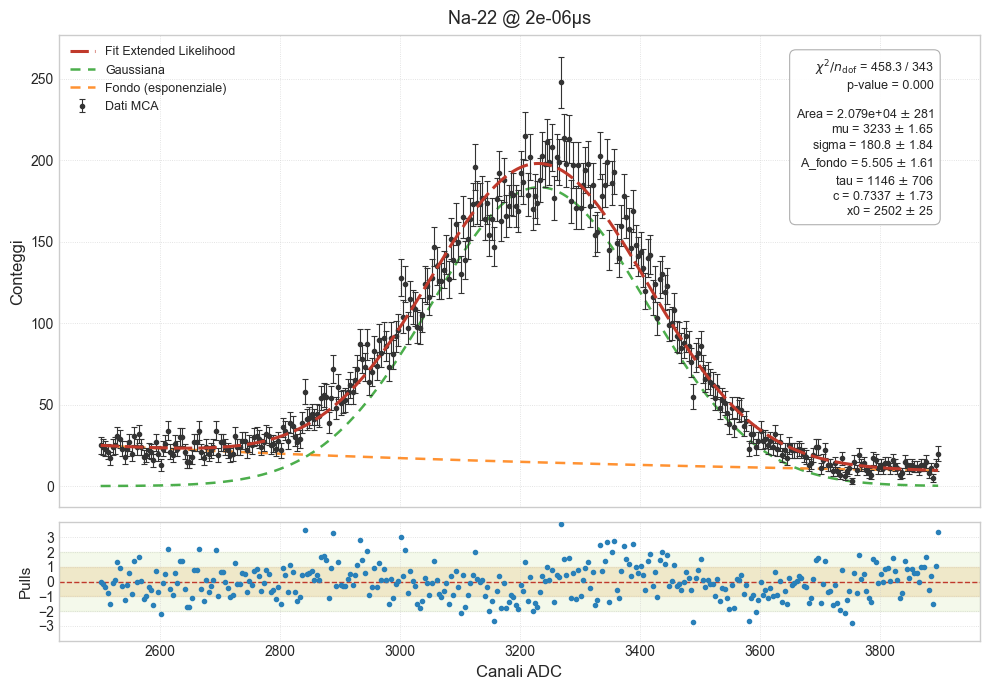

  → Risoluzione R = 0.1317+/-0.0013

  Shaping-Time = 3e-06 (Taglio tra 2500 e 3900)


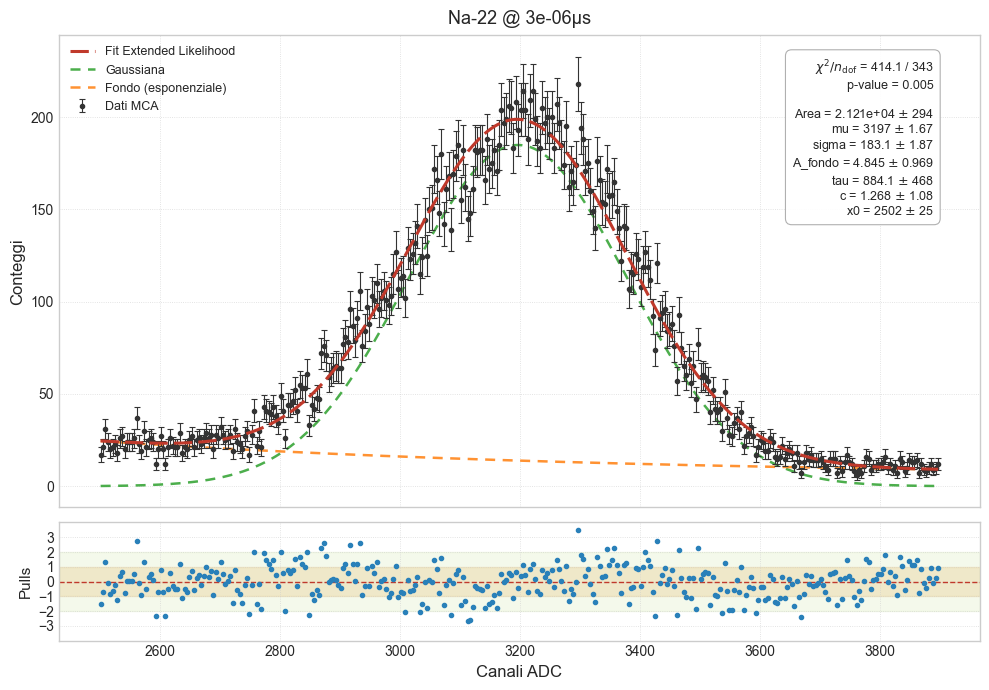

  → Risoluzione R = 0.1348+/-0.0014

  Shaping-Time = 6e-06 (Taglio tra 2500 e 3900)


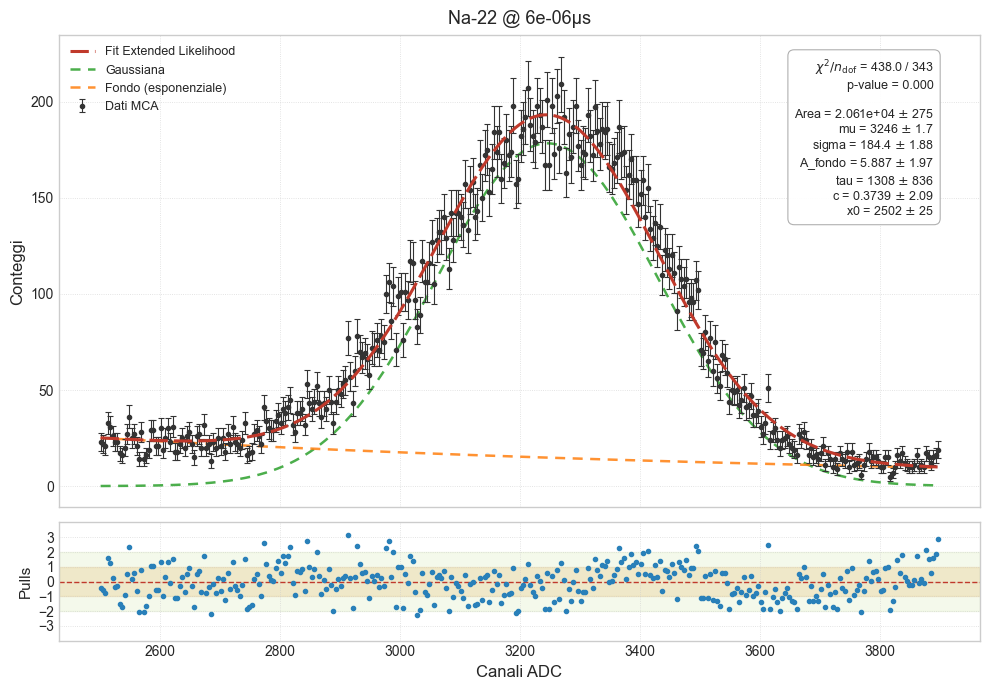

  → Risoluzione R = 0.1338+/-0.0014

  Shaping-Time = 9.999999999999999e-06 (Taglio tra 2500 e 3900)


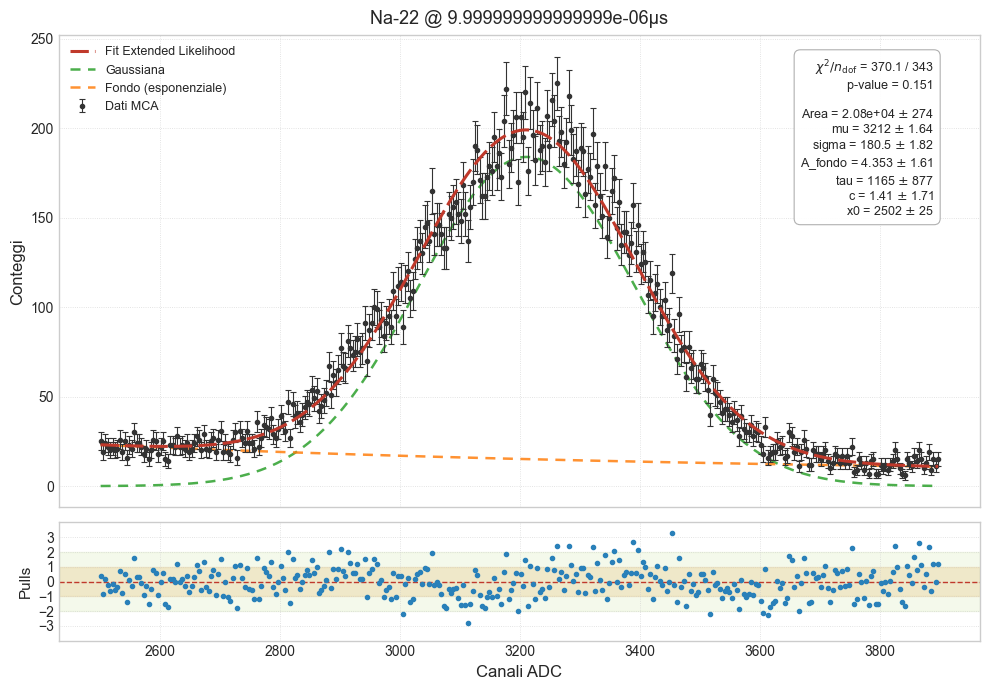

  → Risoluzione R = 0.1323+/-0.0013


In [18]:
ch_v_max_array = np.array([3200, 3300, 3900, 3900, 3900, 3900])
ch_v_min_array = np.array([2150, 2600, 2500, 2500, 2500, 2500])

times = np.array([0.5, 1, 2, 3, 6, 10]) * (1e-6)
risultati_shaping = []

for filename, t, c_v_min, c_v_max in zip(file_shaping_list, times, ch_v_min_array, ch_v_max_array):
    
    print(f"\n{'='*60}")
    print(f"  Shaping-Time = {t} (Taglio tra {c_v_min} e {c_v_max})")
    print(f"{'='*60}")
    
    percorso_completo = os.path.join(cartella_dati, filename)
    canali, conteggi = lib.estrai_spettro(percorso_completo, show_plot=False)
    canali, conteggi = lib.rebin(canali, conteggi, n=4)

    # 3. Ora c_min e c_max sono numeri singoli esatti per questo specifico file
    mask = (canali >= c_v_min) & (canali <= c_v_max)
    x_picco = canali[mask]
    y_picco = conteggi[mask]
    
    # Stime iniziali
    mu_guess = x_picco[np.argmax(y_picco)]
    area_guess = np.sum(y_picco)
    fondo_guess = np.mean(y_picco[:5])
    sigma_guess = 15
    x0_guess = x_picco[0]
    c_guess = np.mean(y_picco[-5:])
    if c_guess <= 0: c_guess = 1.0

    # 3. Stima dell'altezza dell'esponenziale 'A_fondo' (coda sinistra)
    sinistra_mean = np.mean(y_picco[:5])
    A_fondo_guess = sinistra_mean - c_guess
    if A_fondo_guess <= 0: A_fondo_guess = 10.0 # Sicurezza

    # 4. Stima di 'tau' (un terzo della finestra)
    tau_guess = (x_picco[-1] - x_picco[0]) / 3.0

    # 5. Stime del picco (mu e sigma)
    mu_guess = x_picco[np.argmax(y_picco)]
    sigma_guess = 15.0 # Per i NaI di solito è un valore iniziale eccellente

    # 6. Stima dell'Area (Totale - Area del fondo a trapezio)
    fondo_medio = (sinistra_mean + c_guess) / 2.0
    area_guess = np.sum(y_picco) - (fondo_medio * len(x_picco))
    if area_guess <= 0: area_guess = np.sum(y_picco) * 0.5
    
    # 4. Corretti i parametri per la parabola (a, b, c)
    parametri_iniziali = {
        'Area': area_guess, 
        'mu': mu_guess, 
        'sigma': sigma_guess, 
        'A_fondo': A_fondo_guess,
        'tau': tau_guess,
        'c': fondo_guess,
        'x0': x0_guess
    }
    # 5. Corretti gli assegnamenti di CDF e PDF
    fit = lib.FitLikelihoodBomberone(
        canali=x_picco,
        conteggi=y_picco,
        modello_cdf=lib.picco_esponenziale_cdf,
        modello_pdf=lib.picco_esponenziale_pdf,
        initial_params=parametri_iniziali,
        title=f"Na-22 @ {t}µs"
    )
    
    fit.perform_fit(silent=True)
    fit.plot_results(componenti=[('Gaussiana', lib.funzione_gaussiana_pdf), ('Fondo (esponenziale)', lib.funzione_esponenziale_pdf)])  
    
    if fit.is_fit_valid:
        mu  = ufloat(fit.fit_result['mu'][0], fit.fit_result['mu'][1])
        sig = ufloat(fit.fit_result['sigma'][0], fit.fit_result['sigma'][1])
        
        R = 2.355 * sig / mu
        risultati_shaping.append((t, mu, sig, R))
        print(f"  → Risoluzione R = {R:.4f}")
    else:
        print(f"  ⚠️ Fit non valido per voltaggio {t}µs")

In [19]:
#Adesso sempre tenendo conto della finestra variabile
import itertools
delta = 75  #variazione della finestra

risultati_finestra = []

for filename, t, c_minimo, c_massimo in zip(file_shaping_list, times, ch_v_min_array, ch_v_max_array):
    R_delta = []

    variazioni = [-delta, 0, delta]
    
    for d_minimo, d_massimo in itertools.product(variazioni, repeat=2):
        c_minimo_var = c_minimo + d_minimo
        c_massimo_var = c_massimo + d_massimo

        percorso_completo = os.path.join(cartella_dati, filename)
        canali, conteggi = lib.estrai_spettro(percorso_completo, show_plot=False)
        mask = (canali >= c_minimo_var) & (canali <= c_massimo_var)
        x_picco = canali[mask]
        y_picco = conteggi[mask]


        # Stime iniziali
        mu_guess = x_picco[np.argmax(y_picco)]
        area_guess = np.sum(y_picco)
        fondo_guess = np.mean(y_picco[:5])
        sigma_guess = 15
        x0_guess = x_picco[0]
        c_guess = np.mean(y_picco[-5:])
        if c_guess <= 0: c_guess = 1.0

        # 3. Stima dell'altezza dell'esponenziale 'A_fondo' (coda sinistra)
        sinistra_mean = np.mean(y_picco[:5])
        A_fondo_guess = sinistra_mean - c_guess
        if A_fondo_guess <= 0: A_fondo_guess = 10.0 # Sicurezza

        # 4. Stima di 'tau' (un terzo della finestra)
        tau_guess = (x_picco[-1] - x_picco[0]) / 3.0

        # 5. Stime del picco (mu e sigma)
        mu_guess = x_picco[np.argmax(y_picco)]
        sigma_guess = 15.0 # Per i NaI di solito è un valore iniziale eccellente

        # 6. Stima dell'Area (Totale - Area del fondo a trapezio)
        fondo_medio = (sinistra_mean + c_guess) / 2.0
        area_guess = np.sum(y_picco) - (fondo_medio * len(x_picco))
        if area_guess <= 0: area_guess = np.sum(y_picco) * 0.5
    
        # 4. Corretti i parametri per la parabola (a, b, c)
        parametri = {
        'Area': area_guess, 
        'mu': mu_guess, 
        'sigma': sigma_guess, 
        'A_fondo': A_fondo_guess,
        'tau': tau_guess,
        'c': fondo_guess,
        'x0': x0_guess
        }


        fit_volt = lib.FitLikelihoodBomberone(
            canali = x_picco, conteggi = y_picco, 
            modello_cdf = lib.picco_esponenziale_cdf, modello_pdf = lib.picco_esponenziale_pdf,
            initial_params = parametri, title = f"Fit Variato per Shaping-Times {t}"
        )
        fit_volt.perform_fit(silent=True)
        
        
        if fit_volt.is_fit_valid:
            #fit_volt.print_results()
            R_valore = 2.355 * fit_volt.fit_result['sigma'][0] / fit_volt.fit_result['mu'][0]
            R_delta.append(R_valore)
    
    sigma_sist = np.std(R_delta) if len(R_delta) > 1 else 0.0
    risultati_finestra.append((t, sigma_sist))
    print(f"Shaping-Time {t}: {len(R_delta)} fit validi → σ_sist = {sigma_sist:.6f}")

Shaping-Time 5e-07: 9 fit validi → σ_sist = 0.000695
Shaping-Time 1e-06: 9 fit validi → σ_sist = 0.004369
Shaping-Time 2e-06: 9 fit validi → σ_sist = 0.000393
Shaping-Time 3e-06: 9 fit validi → σ_sist = 0.000383
Shaping-Time 6e-06: 9 fit validi → σ_sist = 0.001101
Shaping-Time 9.999999999999999e-06: 9 fit validi → σ_sist = 0.000228


In [21]:
#Calcolo di R tenendo conto degli errori delle finestre
risultati_validi_shaping = [(t, mu, sig, R) for t, mu, sig, R in risultati_shaping if R is not None]
R_nominali_shaping = np.array([r[3].nominal_value for r in risultati_validi_shaping])
R_errori_shaping   = np.array([r[3].std_dev for r in risultati_validi_shaping])

# Media pesata solo statistica
pesi = 1.0 / R_errori_shaping**2
R_media_shaping = np.sum(pesi * R_nominali_shaping) / np.sum(pesi)
R_media_err_shaping = 1.0 / np.sqrt(np.sum(pesi))
print(f"R media pesata = {R_media_shaping*100:.3f}% ± {R_media_err_shaping*100:.3f}%")

# Media pesata con errore sistematico
R_tot_nominali_shaping = np.array([r[3].nominal_value for r in risultati_validi_shaping])
diz_sist_shaping = dict(risultati_finestra)
R_tot_errori_shaping = np.array([
    np.sqrt(r[3].std_dev**2 + diz_sist_shaping[r[0]]**2)
    for r in risultati_validi_shaping
])
pesi_tot_shaping = 1.0 / R_tot_errori_shaping**2
R_media_tot_shaping = np.sum(pesi_tot_shaping * R_tot_nominali_shaping) / np.sum(pesi_tot_shaping)
R_media_tot_err_shaping = 1.0 / np.sqrt(np.sum(pesi_tot_shaping))
print(f"R media pesata (con sist) = {R_media_tot_shaping*100:.3f}% ± {R_media_tot_err_shaping*100:.3f}%")
'''
print("\n" + "="*60)
print("  TEST DI COMPATIBILITÀ CON ERRORE SISTEMATICO")
print("="*60)
for i, (t, mu, sig, R) in enumerate(risultati_validi_shaping):
    sigma_tot_shaping = R_tot_errori_shaping[i]
    print(f"\n  [σ_stat={R.std_dev:.5f}, σ_sist={diz_sist_shaping[t]:.5f}, σ_tot={sigma_tot_shaping:.5f}]")
    lib.test_compatibilita(
        R.nominal_value, R_media_tot_shaping,
        sigma_tot_shaping, R_media_tot_err_shaping,
        val1_name=f"R(volt={t})",
        val2_name="R_media"
    )'''

# Chi2 globale con errori totali
chi2_compat_tot = np.sum(((R_tot_nominali_shaping - R_media_tot_shaping) / R_tot_errori_shaping)**2)
ndof_tot = len(R_tot_nominali_shaping) - 1
p_val_tot = 1 - sc.chi2.cdf(chi2_compat_tot, ndof_tot)
print(f"\nChi2 globale (con sist): {chi2_compat_tot:.2f} / {ndof_tot} ndof")
print(f"p-value = {p_val_tot:.4f}")
if p_val_tot > 0.05:
    print("→ Le R sono COMPATIBILI (includendo l'errore sistematico).")
else:
    print("→ Le R NON sono compatibili anche con l'errore sistematico.")

R media pesata = 13.221% ± 0.059%
R media pesata (con sist) = 13.232% ± 0.065%

Chi2 globale (con sist): 8.14 / 5 ndof
p-value = 0.1487
→ Le R sono COMPATIBILI (includendo l'errore sistematico).


C:\Users\Andrea\AppData\Local\Temp\ipykernel_17908\3410113488.py:25: UserWarning: Glyph 8853 (\N{CIRCLED PLUS}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Andrea\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8853 (\N{CIRCLED PLUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


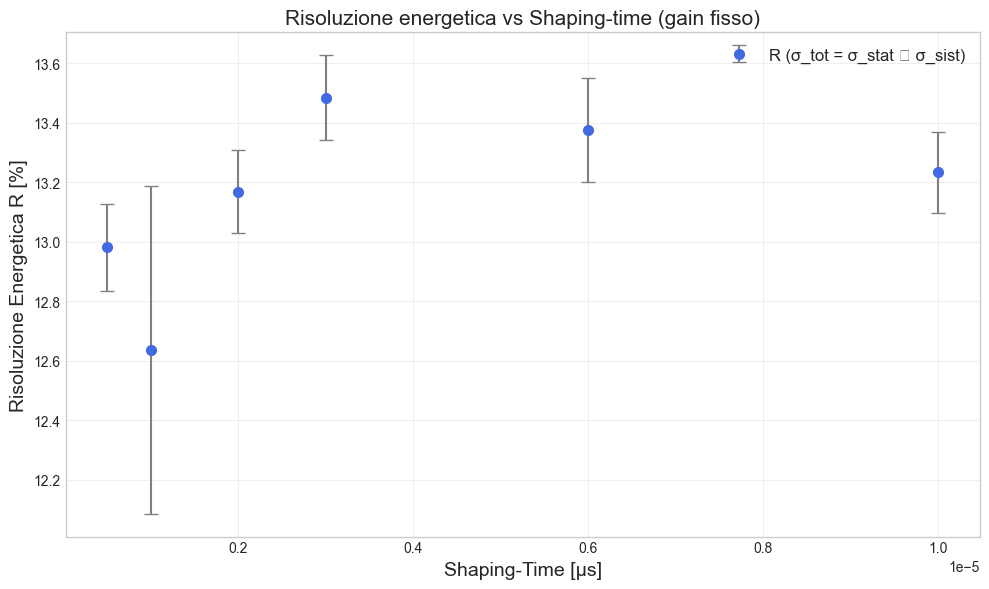

In [22]:
#Adesso dovrei o fare un grafico per R in funzione di V e nel caso interpolare R con una parabola ad esempio così da trovare il minimo
risultati_validi_shaping = [(t, mu, sig, R) for t, mu, sig, R in risultati_shaping if R is not None]
R_nominali_shaping = np.array([r[3].nominal_value for r in risultati_validi_shaping])
diz_sist_shaping = dict(risultati_finestra)
R_tot_errori_shaping = np.array([
    np.sqrt(r[3].std_dev**2 + diz_sist_shaping[r[0]]**2)
    for i, r in enumerate(risultati_validi_shaping)
])  #Questo anche con errori dati dal variare della finestra
t_plot = np.array([r[0] for r in risultati_validi_shaping])


fig, ax = plt.subplots(figsize=(10, 6))
# Plot con errori totali (stat ⊕ sist)
ax.errorbar(t_plot, R_tot_nominali_shaping * 100, yerr=R_tot_errori_shaping * 100,
            fmt='o', capsize=5, markersize=7, color='royalblue',
            ecolor='gray', elinewidth=1.5, label='R (σ_tot = σ_stat ⊕ σ_sist)')
#ax.plot(t_plot[idx_min], R_tot_nominali_shaping[idx_min] * 100, 
        #'*', markersize=18, color='red', zorder=5,
        #label=f'Minimo: t = {t_plot[idx_min]:.0f} µs, R = {R_tot_nominali_shaping[idx_min]*100:.2f}%')
ax.set_xlabel('Shaping-Time [µs]', fontsize=14)
ax.set_ylabel('Risoluzione Energetica R [%]', fontsize=14)
ax.set_title('Risoluzione energetica vs Shaping-time (gain fisso)', fontsize=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
#print(f"\nshaping_time_ottimale = {t_plot[idx_min]:.0f} µs")
#print(f"R_minima = {R_tot_nominali_shaping[idx_min]*100:.3f}% ± {R_tot_errori_shaping[idx_min]*100:.3f}%")


--- Esecuzione Fit con Metodo: Chi2 ---
Fit completato.

--- Risultati del Fit (Chi2) ---
Fit Valido: Sì

Parametri Ottimizzati:
  A = 7.269e-09 ± 1.8e-10
  B = 1629 ± 32

Statistiche del Fit:
  Chi-quadro (χ²): 778.8032
  Gradi di libertà (DoF): 4
  Chi-quadro Ridotto (χ²/DoF): 194.7008
  p-value: 0.0000


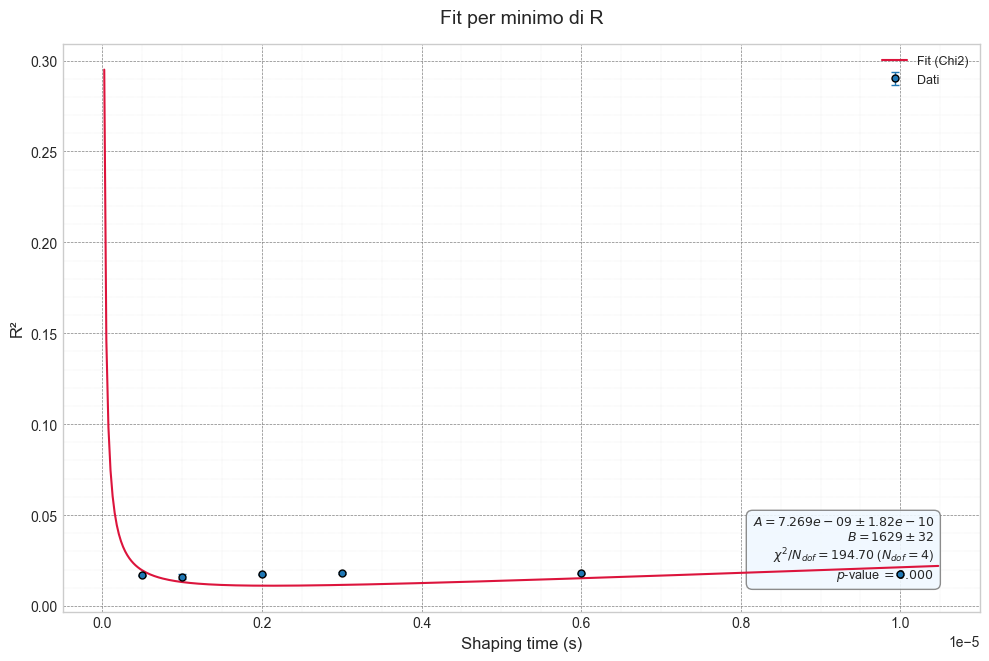

τ_opt = 2.112+/-0.036 µs


In [23]:
from uncertainties import correlated_values

dizionario_sist = dict(risultati_finestra)
R_tot_nominali_shaping = np.array([r[3].nominal_value for r in risultati_validi_shaping])
R_tot_errori_shaping = np.array([
    np.sqrt(r[3].std_dev**2 + dizionario_sist[r[0]]**2)
    for r in risultati_validi_shaping
])
t_plot2 = np.array([r[0] for r in risultati_validi_shaping])


'''def risoluzione_quadra_AB(tau, A, B, C):
    return A/tau + B*tau + C'''

def risoluzione_quadra_AB(tau, A, B):
    C_fisso = (0.065)**2  # risoluzione intrinseca NaI ~ 6.5% → R² ~ 4.2e-3
    return A/tau + B*tau + C_fisso

# Fit su R^2 con errori propagati: sigma_R^2 = 2R * sigma_R
R2_nominali = R_tot_nominali_shaping**2
R2_errori   = 2 * R_tot_nominali_shaping * R_tot_errori_shaping

data_minimo_R2 = {
    'x': t_plot2,
    'y': R2_nominali,
    'sigma_y': R2_errori
}

#parametri_r2 = {'A': 1e-13, 'B': 1e-3, 'C': 0}
parametri_r2 = {'A': 1e-13, 'B': 1e-3}

fit_minimo_R = lib.FitBomberone2(
    model_func=risoluzione_quadra_AB,
    data_arrays=data_minimo_R2,
    initial_params=parametri_r2,
    fit_method='Chi2',
    xlabel='Shaping time (s)',
    ylabel='R²',
    title='Fit per minimo di R'
)
fit_minimo_R.perform_fit()
fit_minimo_R.print_results()
fit_minimo_R.plot_results(log_scale_y=False, log_scale_x=False, info_box_pos='lower right')

# Estrazione tau_opt con covarianza
params_corr = correlated_values(
    [fit_minimo_R.m.values["A"], fit_minimo_R.m.values["B"]],
    fit_minimo_R.m.covariance
)
A_corr, B_corr = params_corr
tau_opt = (A_corr / B_corr) ** 0.5
print(f"τ_opt = {tau_opt*1e6:.3f} µs")

#  Rivelatore GRANDE (2)

In [ ]:
file_shaping_list2 = [
    "histo_2_gain75_st05.dat",
    "histo_2_gain75_st1.dat",
    "histo_2_gain75_st2.dat",
    "histo_2_gain75_st3.dat",
    "histo_2_gain75_st6.dat",
    "histo_2_gain75_st10.dat"
]

times = np.array([0.5, 1, 2, 3, 6, 10]) * (1e-6)




  Shaping-Time = 5e-07 (Taglio tra 2450 e 3300)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 5e-07µs
      Area =  7.233e+04 ± 339.6
        mu =       2881 ± 0.4482
     sigma =      102.7 ± 0.4205
   A_fondo =      20.38 ± 12.28
       tau =       1780 ± 1383
         c =     -4.347 ± 12.38
        x0 =       2454 ± 24.54
--------------------------------------------------
Chi2 / ndof = 296.19 / 205 = 1.44
p-value     = 3.157e-05


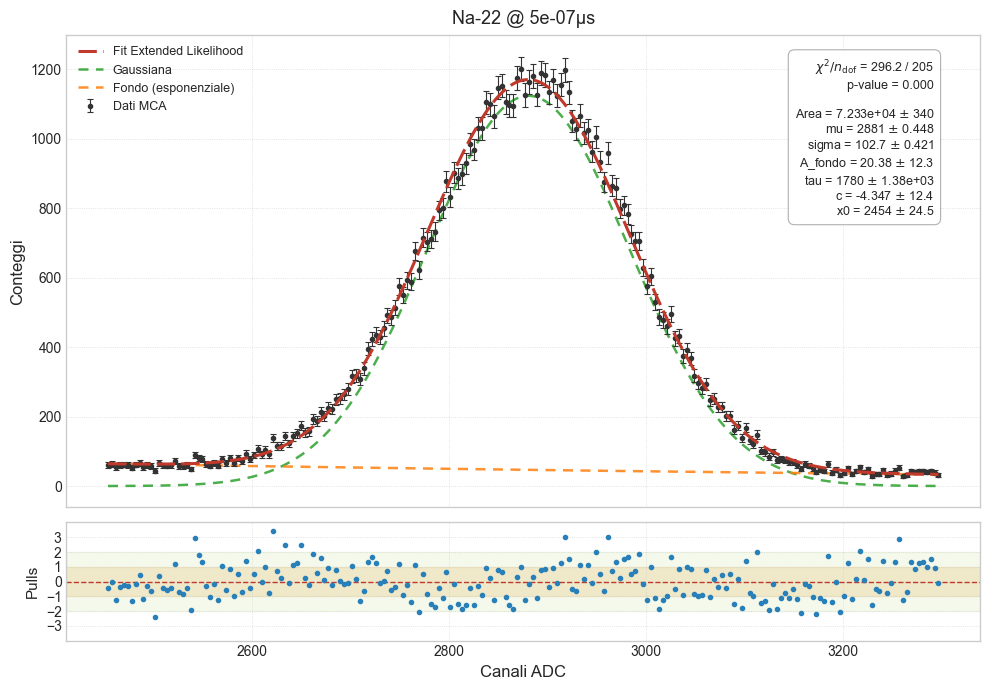

  → Risoluzione R = 0.0840+/-0.0003

  Shaping-Time = 1e-06 (Taglio tra 2650 e 3600)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 1e-06µs
      Area =  7.174e+04 ± 341.5
        mu =       3137 ± 0.4918
     sigma =      112.6 ± 0.464
   A_fondo =      26.32 ± 26.84
       tau =       2941 ± 2941
         c =      -11.7 ± 27.47
        x0 =       2654 ± 26.54
--------------------------------------------------
Chi2 / ndof = 362.49 / 230 = 1.58
p-value     = 5.542e-08


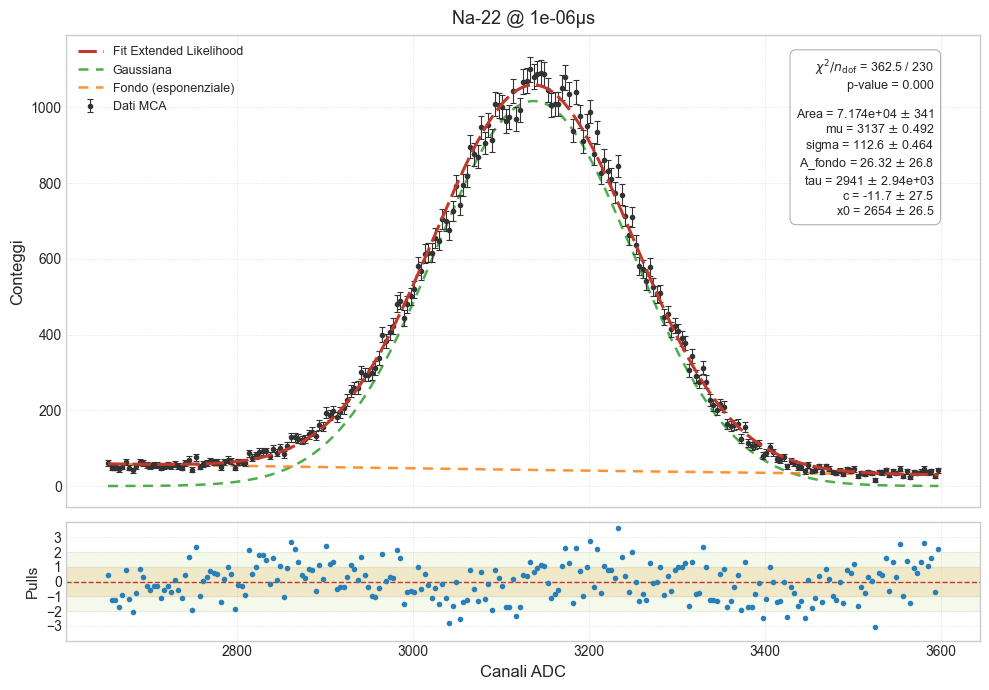

  → Risoluzione R = 0.0845+/-0.0003

  Shaping-Time = 2e-06 (Taglio tra 2900 e 3900)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 2e-06µs
      Area =  7.149e+04 ± 315.2
        mu =       3411 ± 0.5376
     sigma =      122.1 ± 0.4873
   A_fondo =      55.87 ± 11.4
       tau =       8023 ± 1785
         c =     -42.39 ± 11.39
        x0 =       2902 ± 29.02
--------------------------------------------------
Chi2 / ndof = 301.79 / 243 = 1.24
p-value     = 0.006082


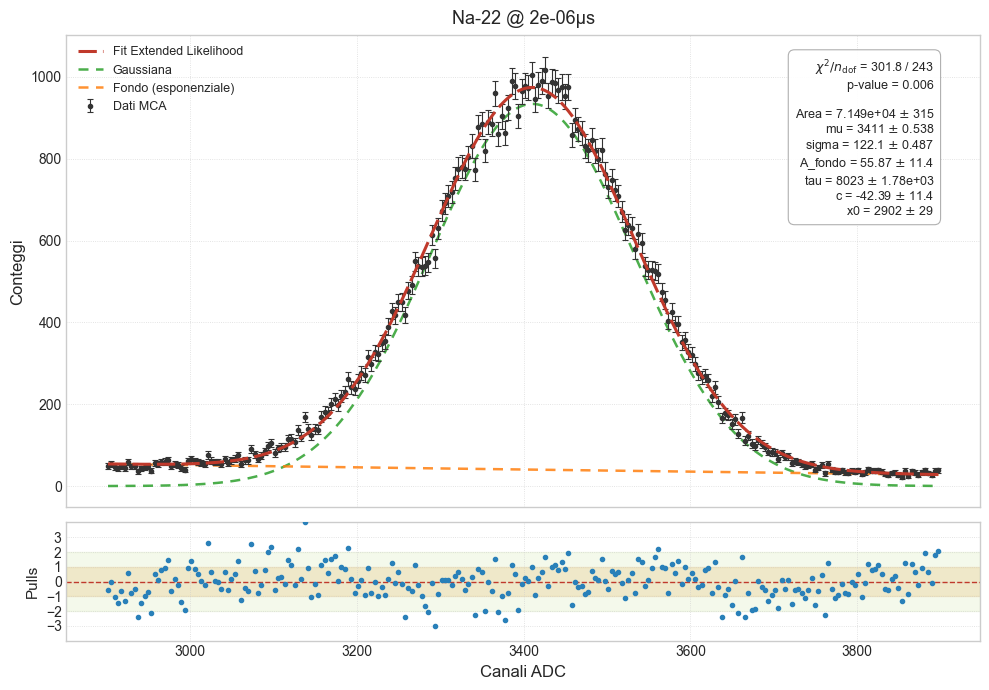

  → Risoluzione R = 0.0843+/-0.0003

  Shaping-Time = 3e-06 (Taglio tra 2850 e 3800)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 3e-06µs
      Area =  7.139e+04 ± 321.1
        mu =       3353 ± 0.5316
     sigma =      120.2 ± 0.4894
   A_fondo =      51.78 ± 25.96
       tau =       6607 ± 3574
         c =     -38.06 ± 25.96
        x0 =       2854 ± 28.54
--------------------------------------------------
Chi2 / ndof = 277.44 / 230 = 1.21
p-value     = 0.01758


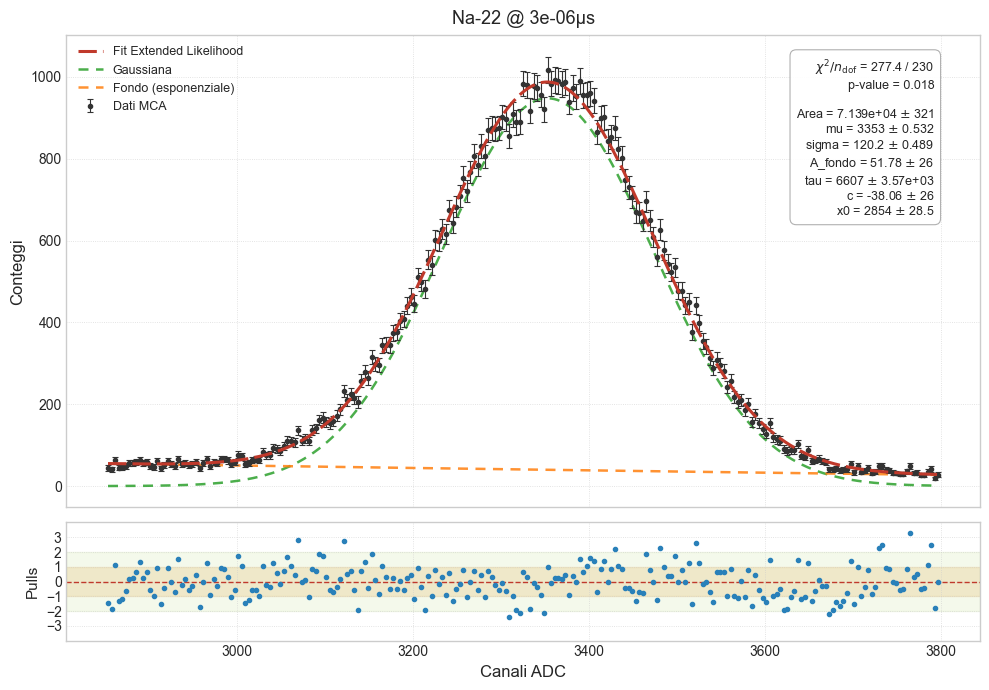

  → Risoluzione R = 0.0844+/-0.0003

  Shaping-Time = 6e-06 (Taglio tra 2900 e 3850)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 6e-06µs
      Area =  6.846e+04 ± 353.2
        mu =       3385 ± 0.555
     sigma =      121.5 ± 0.5415
   A_fondo =      11.54 ± 4.691
       tau =       1217 ± 755.8
         c =      2.156 ± 4.768
        x0 =       2902 ± 29.02
--------------------------------------------------
Chi2 / ndof = 274.65 / 231 = 1.19
p-value     = 0.02583


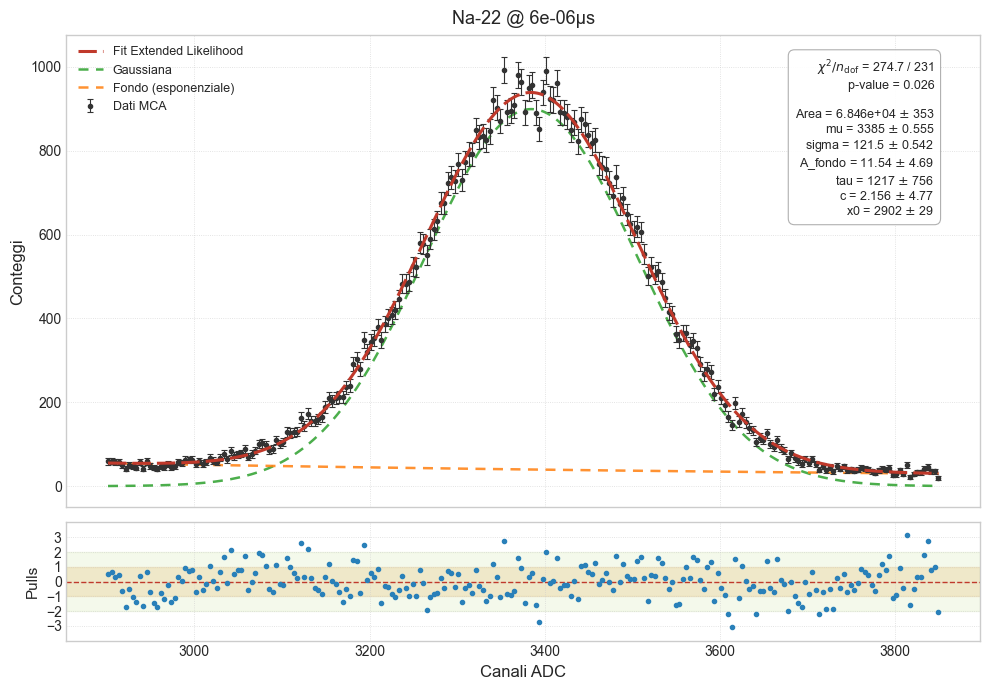

  → Risoluzione R = 0.0845+/-0.0004

  Shaping-Time = 9.999999999999999e-06 (Taglio tra 2800 e 3800)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 9.999999999999999e-06µs
      Area =  6.837e+04 ± 307.6
        mu =       3343 ± 0.5188
     sigma =      120.1 ± 0.4962
   A_fondo =        970 ± 3.186
       tau =   1.68e+05 ± 2656
         c =     -956.6 ± 3.181
        x0 =       2802 ± 28.02
--------------------------------------------------
Chi2 / ndof = 287.00 / 243 = 1.18
p-value     = 0.02764


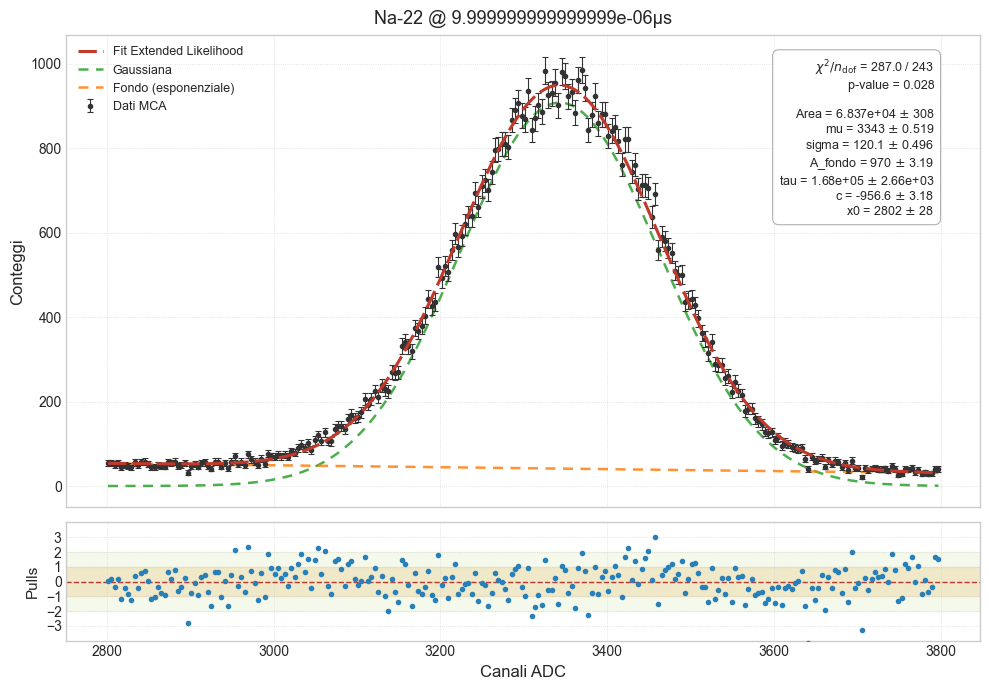

  → Risoluzione R = 0.0846+/-0.0003


In [27]:
ch_v_max_array2 = np.array([3300, 3600, 3900, 3800, 3850, 3800])
ch_v_min_array2 = np.array([2450, 2650, 2900, 2850, 2900, 2800])

risultati_shaping2 = []

for filename, t, c_v_min, c_v_max in zip(file_shaping_list2, times, ch_v_min_array2, ch_v_max_array2):
    print(f"\n{'='*60}")
    print(f"  Shaping-Time = {t} (Taglio tra {c_v_min} e {c_v_max})")
    print(f"{'='*60}")
    
    percorso_completo = os.path.join(cartella_dati, filename)
    canali, conteggi = lib.estrai_spettro(percorso_completo, show_plot=False)
    canali, conteggi = lib.rebin(canali, conteggi, n=4)

    # 3. Ora c_min e c_max sono numeri singoli esatti per questo specifico file
    mask = (canali >= c_v_min) & (canali <= c_v_max)
    x_picco = canali[mask]
    y_picco = conteggi[mask]
    
    # Stime iniziali
    mu_guess = x_picco[np.argmax(y_picco)]
    area_guess = np.sum(y_picco)
    fondo_guess = np.mean(y_picco[:5])
    sigma_guess = 15
    x0_guess = x_picco[0]
    c_guess = np.mean(y_picco[-5:])
    if c_guess <= 0: c_guess = 1.0

    # 3. Stima dell'altezza dell'esponenziale 'A_fondo' (coda sinistra)
    sinistra_mean = np.mean(y_picco[:5])
    A_fondo_guess = sinistra_mean - c_guess
    if A_fondo_guess <= 0: A_fondo_guess = 10.0 # Sicurezza

    # 4. Stima di 'tau' (un terzo della finestra)
    tau_guess = (x_picco[-1] - x_picco[0]) / 3.0

    # 5. Stime del picco (mu e sigma)
    mu_guess = x_picco[np.argmax(y_picco)]
    sigma_guess = 15.0 # Per i NaI di solito è un valore iniziale eccellente

    # 6. Stima dell'Area (Totale - Area del fondo a trapezio)
    fondo_medio = (sinistra_mean + c_guess) / 2.0
    area_guess = np.sum(y_picco) - (fondo_medio * len(x_picco))
    if area_guess <= 0: area_guess = np.sum(y_picco) * 0.5
    
    # 4. Corretti i parametri per la parabola (a, b, c)
    parametri_iniziali = {
        'Area': area_guess, 
        'mu': mu_guess, 
        'sigma': sigma_guess, 
        'A_fondo': A_fondo_guess,
        'tau': tau_guess,
        'c': fondo_guess,
        'x0': x0_guess
    }
    # 5. Corretti gli assegnamenti di CDF e PDF
    fit = lib.FitLikelihoodBomberone(
        canali=x_picco,
        conteggi=y_picco,
        modello_cdf=lib.picco_esponenziale_cdf,
        modello_pdf=lib.picco_esponenziale_pdf,
        initial_params=parametri_iniziali,
        title=f"Na-22 @ {t}µs"
    )
    
    fit.perform_fit()
    fit.plot_results(componenti=[('Gaussiana', lib.funzione_gaussiana_pdf), ('Fondo (esponenziale)', lib.funzione_esponenziale_pdf)])  
    
    if fit.is_fit_valid:
        mu  = ufloat(fit.fit_result['mu'][0], fit.fit_result['mu'][1])
        sig = ufloat(fit.fit_result['sigma'][0], fit.fit_result['sigma'][1])
        
        R = 2.355 * sig / mu
        risultati_shaping2.append((t, mu, sig, R))
        print(f"  → Risoluzione R = {R:.4f}")
    else:
        print(f"  ⚠️ Fit non valido per voltaggio {t}µs")

In [12]:
#Adesso sempre tenendo conto della finestra variabile
import itertools
delta = 75  #variazione della finestra

risultati_finestra2 = []

for filename, t, c_minimo, c_massimo in zip(file_shaping_list2, times, ch_v_min_array2, ch_v_max_array2):
    R_delta = []

    variazioni = [-delta, 0, delta]
    
    for d_minimo, d_massimo in itertools.product(variazioni, repeat=2):
        c_minimo_var = c_minimo + d_minimo
        c_massimo_var = c_massimo + d_massimo

        percorso_completo = os.path.join(cartella_dati, filename)
        canali, conteggi = lib.estrai_spettro(percorso_completo, show_plot=False)
        mask = (canali >= c_minimo_var) & (canali <= c_massimo_var)
        x_picco = canali[mask]
        y_picco = conteggi[mask]


        # Stime iniziali
        mu_guess = x_picco[np.argmax(y_picco)]
        area_guess = np.sum(y_picco)
        fondo_guess = np.mean(y_picco[:5])
        sigma_guess = 15
        x0_guess = x_picco[0]
        c_guess = np.mean(y_picco[-5:])
        if c_guess <= 0: c_guess = 1.0

        # 3. Stima dell'altezza dell'esponenziale 'A_fondo' (coda sinistra)
        sinistra_mean = np.mean(y_picco[:5])
        A_fondo_guess = sinistra_mean - c_guess
        if A_fondo_guess <= 0: A_fondo_guess = 10.0 # Sicurezza

        # 4. Stima di 'tau' (un terzo della finestra)
        tau_guess = (x_picco[-1] - x_picco[0]) / 3.0

        # 5. Stime del picco (mu e sigma)
        mu_guess = x_picco[np.argmax(y_picco)]
        sigma_guess = 15.0 # Per i NaI di solito è un valore iniziale eccellente

        # 6. Stima dell'Area (Totale - Area del fondo a trapezio)
        fondo_medio = (sinistra_mean + c_guess) / 2.0
        area_guess = np.sum(y_picco) - (fondo_medio * len(x_picco))
        if area_guess <= 0: area_guess = np.sum(y_picco) * 0.5
    
        # 4. Corretti i parametri per la parabola (a, b, c)
        parametri = {
        'Area': area_guess, 
        'mu': mu_guess, 
        'sigma': sigma_guess, 
        'A_fondo': A_fondo_guess,
        'tau': tau_guess,
        'c': fondo_guess,
        'x0': x0_guess
        }


        fit_volt = lib.FitLikelihoodBomberone(
            canali = x_picco, conteggi = y_picco, 
            modello_cdf = lib.picco_esponenziale_cdf, modello_pdf = lib.picco_esponenziale_pdf,
            initial_params = parametri, title = f"Fit Variato per Shaping-Times {t}"
        )
        fit_volt.perform_fit(silent=True)
        
        
        if fit_volt.is_fit_valid:
            #fit_volt.print_results()
            R_valore2 = 2.355 * fit_volt.fit_result['sigma'][0] / fit_volt.fit_result['mu'][0]
            R_delta.append(R_valore2)
    
    sigma_sist2 = np.std(R_delta) if len(R_delta) > 1 else 0.0
    risultati_finestra2.append((t, sigma_sist2))
    print(f"Shaping-Time {t}: {len(R_delta)} fit validi → σ_sist = {sigma_sist2:.6f}")

Shaping-Time 5e-07: 9 fit validi → σ_sist = 0.000125
Shaping-Time 1e-06: 9 fit validi → σ_sist = 0.000094
Shaping-Time 2e-06: 9 fit validi → σ_sist = 0.000260
Shaping-Time 3e-06: 9 fit validi → σ_sist = 0.000143
Shaping-Time 6e-06: 9 fit validi → σ_sist = 0.000199
Shaping-Time 9.999999999999999e-06: 9 fit validi → σ_sist = 0.000128


In [28]:
#Calcolo di R tenendo conto degli errori delle finestre
risultati_validi_shaping2 = [(t, mu, sig, R) for t, mu, sig, R in risultati_shaping2 if R is not None]
R_nominali_shaping2 = np.array([r[3].nominal_value for r in risultati_validi_shaping2])
R_errori_shaping2   = np.array([r[3].std_dev for r in risultati_validi_shaping2])

# Media pesata solo statistica
pesi2 = 1.0 / R_errori_shaping2**2
R_media_shaping2 = np.sum(pesi2 * R_nominali_shaping2) / np.sum(pesi2)
R_media_err_shaping2 = 1.0 / np.sqrt(np.sum(pesi2))
print(f"R media pesata = {R_media_shaping2*100:.3f}% ± {R_media_err_shaping2*100:.3f}%")

# Media pesata con errore sistematico
R_tot_nominali_shaping2 = np.array([r[3].nominal_value for r in risultati_validi_shaping2])
diz_sist_shaping2 = dict(risultati_finestra2)
R_tot_errori_shaping2 = np.array([
    np.sqrt(r[3].std_dev**2 + diz_sist_shaping2[r[0]]**2)
    for r in risultati_validi_shaping2
])
pesi_tot_shaping2 = 1.0 / R_tot_errori_shaping2**2
R_media_tot_shaping2 = np.sum(pesi_tot_shaping2 * R_tot_nominali_shaping2) / np.sum(pesi_tot_shaping2)
R_media_tot_err_shaping2 = 1.0 / np.sqrt(np.sum(pesi_tot_shaping2))
print(f"R media pesata (con sist) = {R_media_tot_shaping2*100:.3f}% ± {R_media_tot_err_shaping2*100:.3f}%")
'''
print("\n" + "="*60)
print("  TEST DI COMPATIBILITÀ CON ERRORE SISTEMATICO")
print("="*60)
for i, (t, mu, sig, R) in enumerate(risultati_validi_shaping2):
    sigma_tot_shaping2 = R_tot_errori_shaping2[i]
    print(f"\n  [σ_stat={R.std_dev:.5f}, σ_sist={diz_sist_shaping2[t]:.5f}, σ_tot={sigma_tot_shaping2:.5f}]")
    lib.test_compatibilita(
        R.nominal_value, R_media_tot_shaping2,
        sigma_tot_shaping2, R_media_tot_err_shaping2,
        val1_name=f"R(Shaping_time={t})",
        val2_name="R_media"
    )'''

# Chi2 globale con errori totali
chi2_compat_tot2 = np.sum(((R_tot_nominali_shaping2 - R_media_tot_shaping2) / R_tot_errori_shaping2)**2)
ndof_tot2 = len(R_tot_nominali_shaping2) - 1
p_val_tot2 = 1 - sc.chi2.cdf(chi2_compat_tot2, ndof_tot2)
print(f"\nChi2 globale (con sist): {chi2_compat_tot2:.2f} / {ndof_tot2} ndof")
print(f"p-value = {p_val_tot2:.4f}")
if p_val_tot2 > 0.05:
    print("→ Le R sono COMPATIBILI (includendo l'errore sistematico).")
else:
    print("→ Le R NON sono compatibili anche con l'errore sistematico.")

R media pesata = 8.438% ± 0.014%
R media pesata (con sist) = 8.439% ± 0.016%

Chi2 globale (con sist): 1.92 / 5 ndof
p-value = 0.8601
→ Le R sono COMPATIBILI (includendo l'errore sistematico).


--- Esecuzione Fit con Metodo: Chi2 ---
Fit completato.

--- Risultati del Fit (Chi2) ---
Fit Valido: Sì

Parametri Ottimizzati:
  A = 1.742e-09 ± 2.7e-11
  B = 359.3 ± 5.4

Statistiche del Fit:
  Chi-quadro (χ²): 1296.9323
  Gradi di libertà (DoF): 4
  Chi-quadro Ridotto (χ²/DoF): 324.2331
  p-value: 0.0000


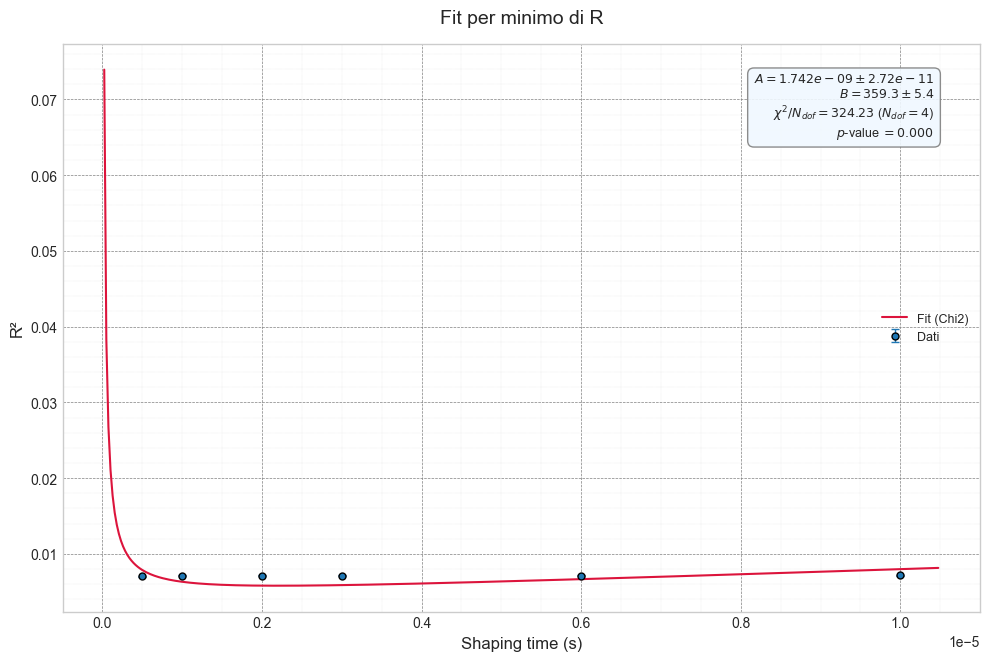

τ_opt = 2.202+/-0.026 µs


In [29]:
from uncertainties import correlated_values

dizionario_sist2 = dict(risultati_finestra2)
R_tot_nominali_shaping2 = np.array([r[3].nominal_value for r in risultati_validi_shaping2])
R_tot_errori_shaping2 = np.array([
    np.sqrt(r[3].std_dev**2 + dizionario_sist2[r[0]]**2)
    for r in risultati_validi_shaping2
])
t_plot2 = np.array([r[0] for r in risultati_validi_shaping2])

def risoluzione_quadra_AB(tau, A, B):
    C_fisso = (0.065)**2  # risoluzione intrinseca NaI ~ 6.5% → R² ~ 4.2e-3
    return A/tau + B*tau + C_fisso

# Fit su R^2 con errori propagati: sigma_R^2 = 2R * sigma_R
R2_nominali2 = R_tot_nominali_shaping2**2
R2_errori2   = 2 * R_tot_nominali_shaping2 * R_tot_errori_shaping2

data_minimo_R22 = {
    'x': t_plot2,
    'y': R2_nominali2,
    'sigma_y': R2_errori2
}

parametri_r22 = {'A': 1e-13, 'B': 1e-3}

fit_minimo_R2 = lib.FitBomberone2(
    model_func=risoluzione_quadra_AB,
    data_arrays=data_minimo_R22,
    initial_params=parametri_r22,
    fit_method='Chi2',
    xlabel='Shaping time (s)',
    ylabel='R²',
    title='Fit per minimo di R'
)
fit_minimo_R2.perform_fit()
fit_minimo_R2.print_results()
fit_minimo_R2.plot_results(log_scale_y=False, log_scale_x=False, info_box_pos='upper right')

# Estrazione tau_opt con covarianza
params_corr2 = correlated_values(
    [fit_minimo_R2.m.values["A"], fit_minimo_R2.m.values["B"]],
    fit_minimo_R2.m.covariance
)
A_corr, B_corr = params_corr2
tau_opt2 = (A_corr / B_corr) ** 0.5
print(f"τ_opt = {tau_opt2*1e6:.3f} µs")

In [30]:
t_tau = lib.test_compatibilita(tau_opt.nominal_value, tau_opt2.nominal_value, tau_opt.std_dev, tau_opt2.std_dev,
                                val1_name=f"t(Shaping-Time Rivelatore Piccolo)", val2_name=f"t(Shaping-Time Rivelatore Grande)", use_ttest=True, custom_df=8)


tau_medio, sigma_tau_medio = lib.media_pesata(
    np.array([tau_opt.nominal_value, tau_opt2.nominal_value]),
    np.array([tau_opt.std_dev, tau_opt2.std_dev])
)
print(f"\nMedia pesata di τ_opt: {tau_medio*1e6:.3f} µs ± {sigma_tau_medio*1e6:.3f} µs")


Test di compatibilità tra t(Shaping-Time Rivelatore Piccolo) (2.112e-06 ± 3.63e-08) e t(Shaping-Time Rivelatore Grande) (2.202e-06 ± 2.62e-08):
  Differenza: 8.96e-08
  Incertezza sulla differenza (denominatore di T): 4.48e-08
  Statistica del test (T o Z): 2.00
  Distribuzione usata: t di Student (df=8.00)
  P-value (due code): 0.0805
  I due valori sono COMPATIBILI (p > 0.05).

Media pesata di τ_opt: 2.171 µs ± 0.021 µs
